In [1]:
import os
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn import metrics

2026-01-02 14:33:25.515576: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def ela(image_path, scale=(224, 224), quality=90):
    image = Image.open(image_path).convert("RGB")
    image = image.resize(scale)

    buffer = BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)

    compressed = Image.open(buffer)

    diff = np.abs(
        np.array(image, dtype=np.int16) - np.array(compressed, dtype=np.int16)
    )
    diff = np.clip(diff * 10, 0, 255).astype(np.uint8)

    return diff

In [3]:
model_path = os.path.join("models", "ela_face_classifier.keras")
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully.")

I0000 00:00:1767357207.332457  176693 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2597 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model loaded successfully.


In [4]:
IMAGE_SIZE = (224, 224)
BASE_DIR = "data"
CLASSES = ["fake", "real"]

X = []
y_true = []
paths = []

for label, cls in enumerate(CLASSES):
    folder = os.path.join(BASE_DIR, cls)

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(folder, file)

            ela_img = ela(img_path, IMAGE_SIZE)
            ela_img = ela_img.astype(np.float32) / 255.0

            X.append(ela_img)
            y_true.append(label)
            paths.append(img_path)

X = np.array(X)
y_true = np.array(y_true)

print(f"Loaded {len(X)} images")


Loaded 20 images


In [5]:
y_pred_probs = model.predict(X, batch_size=32)
y_pred = np.argmax(y_pred_probs, axis=1)

2026-01-02 14:33:28.621739: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f4770088d50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-02 14:33:28.621768: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti, Compute Capability 7.5
2026-01-02 14:33:28.638606: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-02 14:33:28.680395: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500
2026-01-02 14:33:28.939198: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


I0000 00:00:1767357209.960096  176791 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [6]:
print(metrics.classification_report(y_true, y_pred, target_names=CLASSES))

print("ROC AUC:", metrics.roc_auc_score(y_true, y_pred))
print("Average Precision:", metrics.average_precision_score(y_true, y_pred))

              precision    recall  f1-score   support

        fake       1.00      0.90      0.95        10
        real       0.91      1.00      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20

ROC AUC: 0.9500000000000001
Average Precision: 0.9090909090909091


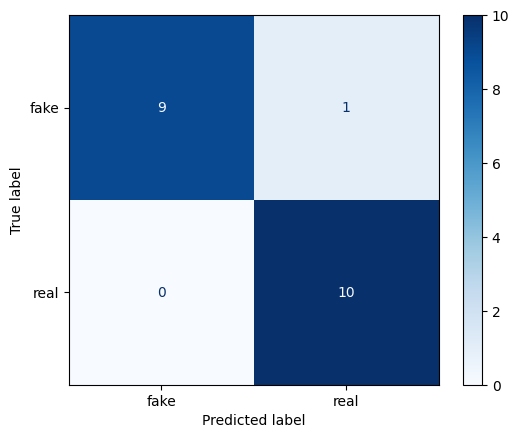

In [7]:
cm = metrics.confusion_matrix(y_true, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap="Blues")
plt.show()

In [8]:
for i in range(len(paths)):
    if y_true[i] != y_pred[i]:
        print(
            f"WRONG | {paths[i]} | "
            f"GT: {CLASSES[y_true[i]]} | "
            f"PRED: {CLASSES[y_pred[i]]}"
        )

WRONG | data/fake/6.jpg | GT: fake | PRED: real


In [9]:
def show_prediction_grid(
    paths,
    y_true,
    y_pred,
    class_names,
    grid_size=(4, 5),
    max_images=20,
):
    idxs = np.random.choice(len(paths), min(max_images, len(paths)), replace=False)

    rows, cols = grid_size
    plt.figure(figsize=(cols * 3, rows * 3))

    for i, idx in enumerate(idxs):
        if i >= rows * cols:
            break

        img = Image.open(paths[idx]).convert("RGB")

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        color = "green" if true_label == pred_label else "red"

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"P: {pred_label}\nGT: {true_label}", color=color, fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


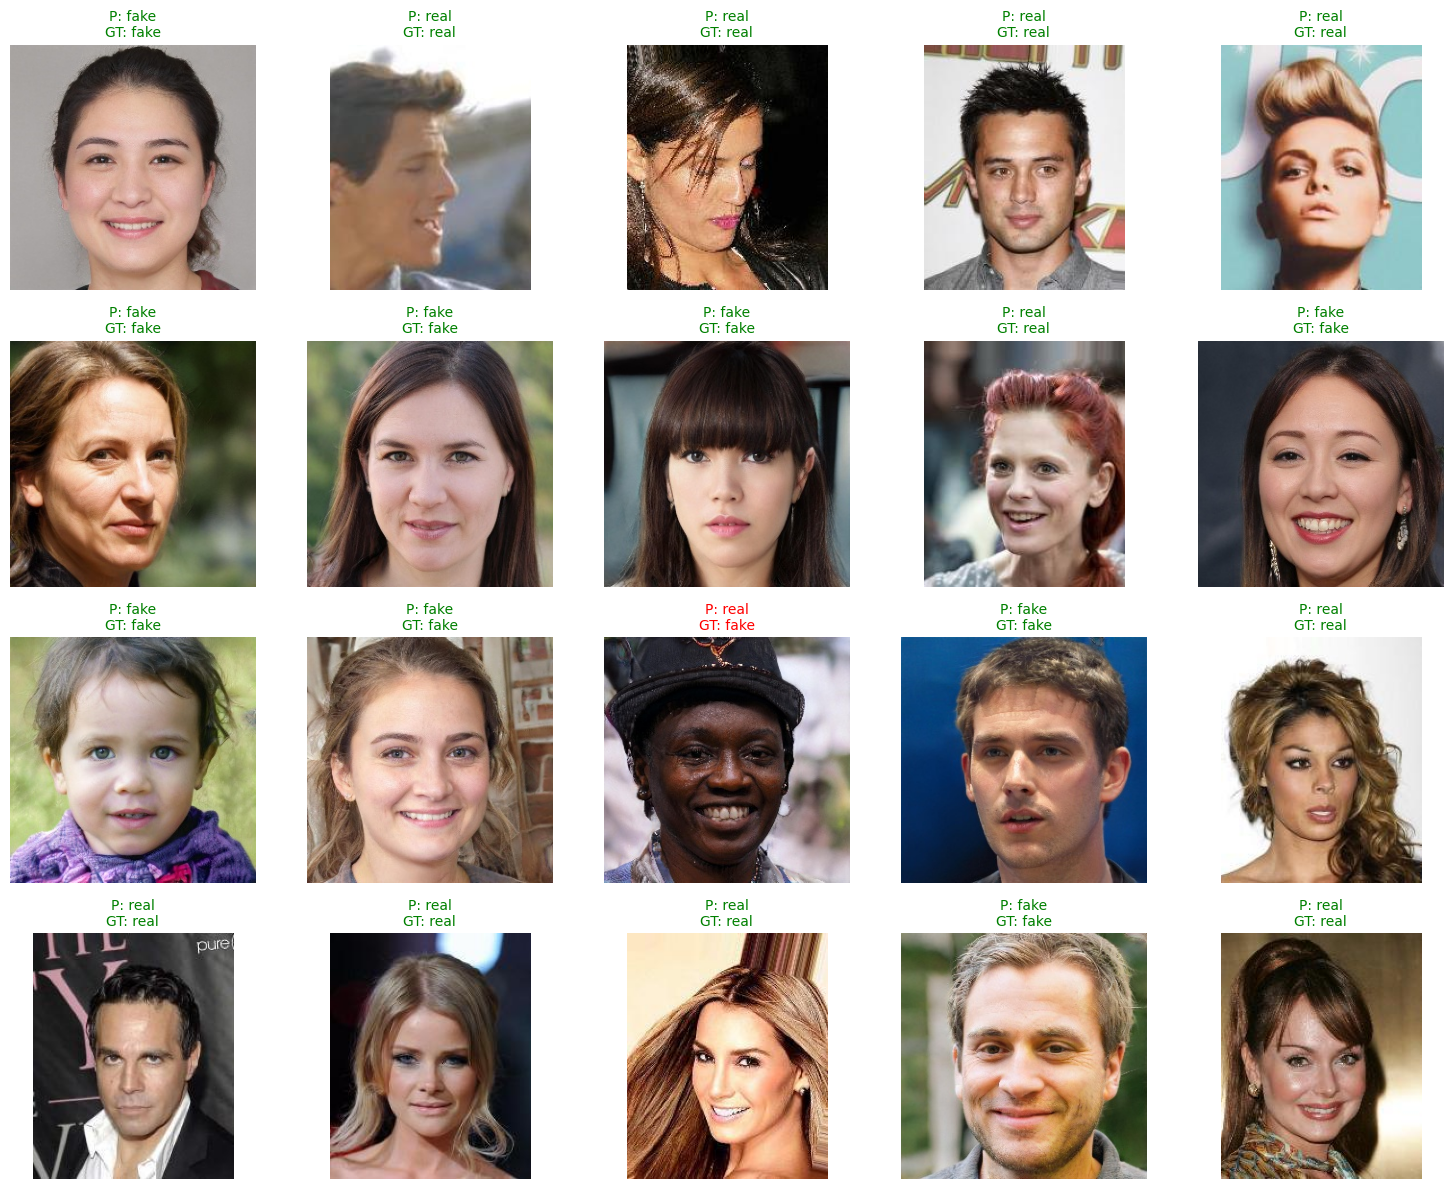

In [10]:
show_prediction_grid(
    paths=paths,
    y_true=y_true,
    y_pred=y_pred,
    class_names=CLASSES,
    grid_size=(4, 5),
    max_images=20,
)